In [1]:
import numpy as np
import pandas as pd


In [17]:
import matplotlib.pyplot as plt

In [31]:
import nolds

In [34]:
from sklearn.metrics import mutual_info_score

In [55]:
import plotly.graph_objects as go

In [9]:
n=9

In [65]:
df = pd.read_parquet("/Users/liuzeyang/Projects/TTMs_try/final_experiment/measure_performance/preds.parquet")
preds = df[df['n']==n].iloc[:,:1024].values

In [11]:
X = pd.read_parquet("/Users/liuzeyang/Projects/TTMs_try/final_experiment/data_generation/data_vary_n.parquet")[f"{n}"].values

In [15]:
samples = []
for i in range(400):
    context = X[9000-512+10*i:9000+10*i]
    future = X[9000+10*i:9000+10*i+1024]
    samples.append((context, future))

contexts = np.stack([c for c,_ in samples])
futures = np.stack([f for _,f in samples])


# MSE

In [23]:
np.mean((preds[:400,-512:] - futures[:,-512:])**2)

np.float64(0.037275180505438515)

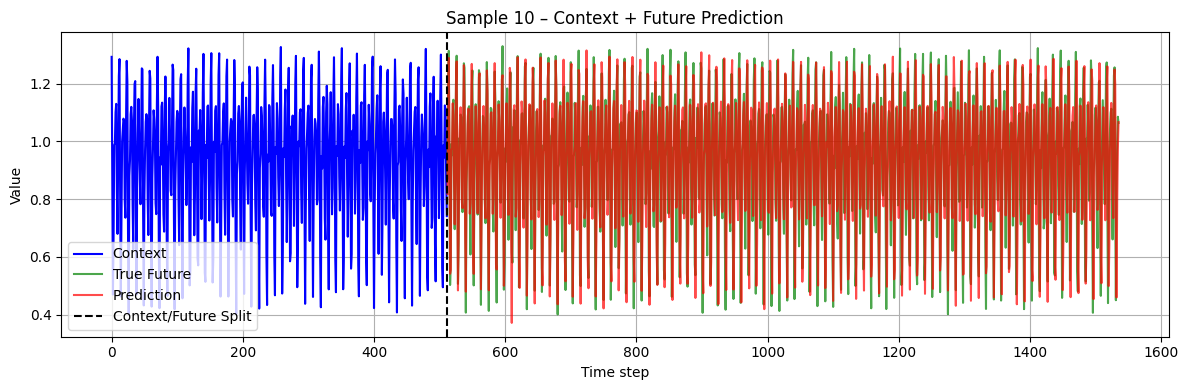

In [30]:
indx = 10

context = contexts[indx]
true_future = futures[indx]
prediction = preds[indx]



# Concatenate context with true and predicted futures for plotting
x_context = np.arange(len(context))
x_future = np.arange(len(context), len(context) + len(true_future))

plt.figure(figsize=(12, 4))

# Plot context (past)
plt.plot(x_context, context, label="Context", color='blue')

# Plot ground truth future
plt.plot(x_future, true_future, label="True Future", color='green',alpha = 0.7)

# Plot predicted future
plt.plot(x_future, prediction, label="Prediction", color='red', alpha=0.7)

# Vertical dashed line separating context and future
plt.axvline(x=len(context) - 0.5, color='black', linestyle='--', label='Context/Future Split')

# Labels and legend
plt.title(f"Sample {indx} – Context + Future Prediction")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
def psd_mf_compute(x):
    n = len(x)
    fft_vals = np.fft.rfft(x,n)
    psd = np.abs(fft_vals)**2
    freqs = np.fft.rfftfreq(n)
    mean_freq = np.sum(freqs[1:] * psd[1:]) / np.sum(psd[1:])  
    return psd, mean_freq

def ami_1stm_compute(x, max_lag=100, bins=64):
    # Discretize data into bins
    _, bin_edges = np.histogram(x, bins=bins)
    digitized = np.digitize(x, bin_edges[:-1])

    ami = []
    for lag in range(1, max_lag):
        x1 = digitized[:-lag]
        x2 = digitized[lag:]
        mi = mutual_info_score(x1, x2)
        ami.append(mi)
    
    # Find the first local minimum
    for i in range(1, len(ami) - 1):
        if ami[i] < ami[i-1] and ami[i] < ami[i+1]:
            return ami,i + 1  # +1 because lag starts at 1
        
    return ami, np.argmin(ami) + 1

def le_compute(x):
    # Compute the Lyapunov exponent
    _,mf = psd_mf_compute(x)
    min_tsep = int(round(1/mf))
    _,lag = ami_1stm_compute(x,bins = 100)
    le = nolds.lyap_r(x,min_tsep=min_tsep,lag=lag)
    
    return le


In [38]:
les_p = np.array([le_compute(seq) for seq in preds[:400,:]])
les_t = np.array([le_compute(seq) for seq in futures[:400,:]])


/Users/liuzeyang/Projects/TTMs_try/TTMTvenv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/liuzeyang/Projects/TTMs_try/TTMTvenv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [42]:
futures

array([[0.53785092, 0.73710962, 1.06811615, ..., 0.88219156, 1.17462066,
        1.30113896],
       [0.76949839, 0.44246532, 0.81115367, ..., 0.84608691, 0.74563303,
        0.93706154],
       [1.28446842, 1.16340373, 0.64697562, ..., 1.10587933, 1.15950956,
        0.84438675],
       ...,
       [1.11903647, 0.93711104, 0.74523138, ..., 0.88763396, 0.54023069,
        0.67592731],
       [0.95021221, 1.12674377, 1.09466232, ..., 1.30204667, 0.92493134,
        0.50292147],
       [0.61603187, 0.98102596, 0.95066195, ..., 0.92110958, 1.21766441,
        1.30177906]], shape=(400, 1024))

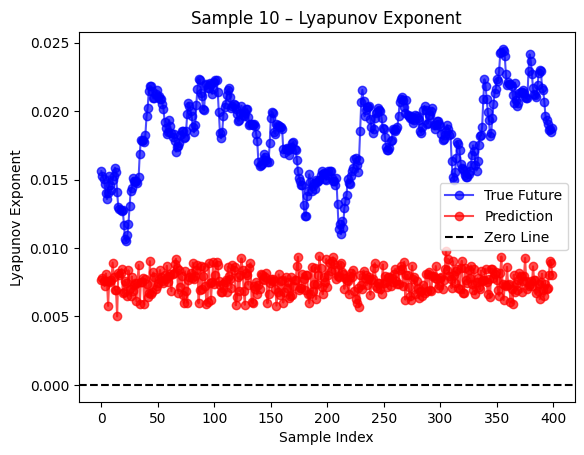

In [48]:
plt.plot(les_t, label="True Future", color='blue',marker='o', alpha=0.7)
plt.plot(les_p, label="Prediction", color='red', marker='o', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--', label='Zero Line')
plt.title(f"Sample {indx} – Lyapunov Exponent")
plt.xlabel("Sample Index")
plt.ylabel("Lyapunov Exponent")
plt.legend()

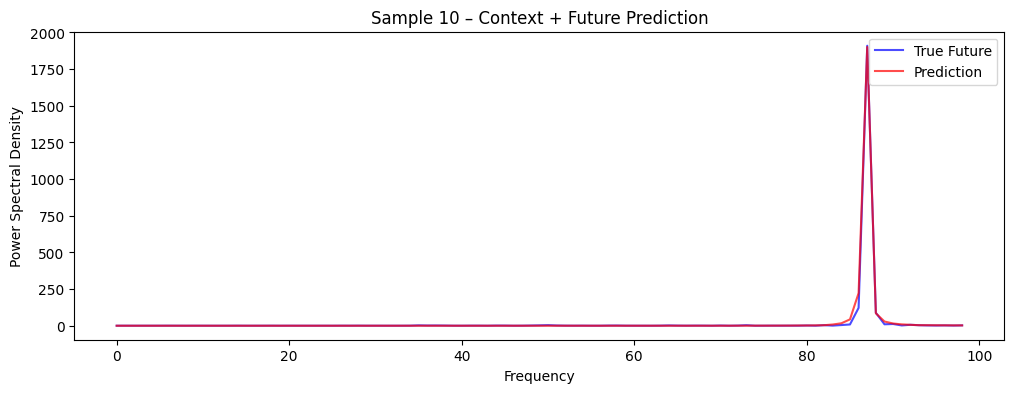

In [ ]:
indx = 10

context = contexts[indx]
true_future = futures[indx]
prediction = preds[indx]

psd_p,_ = psd_mf_compute(prediction)
psd_t,_ = psd_mf_compute(true_future)

plt.figure(figsize=(12, 4))
plt.plot(psd_t[1:100], label="True Future", color='blue', alpha=0.7)
plt.plot(psd_p[1:100], label="Prediction", color='red', alpha=0.7)
plt.title(f"Sample {indx} – Context + Future Prediction Power Spectral Density")
plt.xlabel("Frequency")
plt.ylabel("Power Spectral Density")
plt.legend()



In [49]:
def delay_embedding(data, d, tau):
    N = len(data)
    indices = np.arange(d) * tau + np.arange(N - (d - 1) * tau)[:, None]
    return data[indices]

In [80]:
X_de = delay_embedding(X, 3, 1)
preds_pertubation_des = np.array([delay_embedding(seq, 3, 1) for seq in preds[400:,:]])
preds_des = np.array([delay_embedding(seq,3,1) for seq in preds[:400,:]])

In [81]:
preds_des

array([[[0.4880004 , 0.7235213 , 1.0705943 ],
        [0.7235213 , 1.0705943 , 1.1182413 ],
        [1.0705943 , 1.1182413 , 1.0554345 ],
        ...,
        [1.1145998 , 1.0919328 , 0.87597585],
        [1.0919328 , 0.87597585, 0.7327963 ],
        [0.87597585, 0.7327963 , 0.93925625]],

       [[0.8890638 , 0.48066422, 0.6818955 ],
        [0.48066422, 0.6818955 , 1.0077916 ],
        [0.6818955 , 1.0077916 , 0.98522747],
        ...,
        [0.9543978 , 1.0659151 , 1.1222566 ],
        [1.0659151 , 1.1222566 , 1.0146106 ],
        [1.1222566 , 1.0146106 , 0.77859753]],

       [[1.2855844 , 1.2170264 , 0.7246954 ],
        [1.2170264 , 0.7246954 , 0.42090213],
        [0.7246954 , 0.42090213, 0.8182108 ],
        ...,
        [0.56471264, 0.94265896, 1.0047817 ],
        [0.94265896, 1.0047817 , 1.1170352 ],
        [1.0047817 , 1.1170352 , 1.0737561 ]],

       ...,

       [[1.1058704 , 0.94182765, 0.76000726],
        [0.94182765, 0.76000726, 0.7899713 ],
        [0.76000726, 0

In [76]:
indx = 400
fig = go.Figure(data=[
    go.Scatter3d(
        x=X_de[10000:,0], 
        y=X_de[10000:,1], 
        z=X_de[10000:,2],
        mode='lines',
        line=dict(width=0.5, color='rgba(0,0,256,0.7)')
    ),
    go.Scatter3d(
        x=preds_pertubation_des[:,indx, 0],  # Change this slice as needed
        y=preds_pertubation_des[:,indx, 1],
        z=preds_pertubation_des[:,indx, 2],
        # mode='lines',
        # line=dict(width=2, color='rgba(255,0,0,0.5)')
        mode='markers',
        marker=dict(size=1, color='rgba(0,255,0,0.7)', symbol='circle')
    )
])

fig.update_layout(title='delay embedding if sensitive to perturbation')
fig.show()

In [82]:
indx = 10
fig = go.Figure(data=[
    go.Scatter3d(
        x=preds_des[indx,:,0], 
        y=preds_des[indx,:,1], 
        z=preds_des[indx,:,2],
        mode='lines',
        line=dict(width=0.5, color='rgba(0,0,256,0.7)')
    )
])


fig.update_layout(title='delay embedding of prediction')
fig.show()